# Language Modeling Fundamentals


#### Part 1: Bigram language models

*Acknowledgements*: The content is based on Andrej Karpathy's makemore bigrams lecture ([[youtube link](https://www.youtube.com/watch?v=PaCmpygFfXo)][[notebook]((https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/makemore/makemore_part1_bigrams.ipynb))]) and  [CMU CS11-711 Advanced NLP](https://cmu-l3.github.io/anlp-fall2025/).

## Bigram language model

\begin{align}
p(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_{t-1})
\end{align}

where $ p(x_t \mid x_{t-1}) $ is the conditional probability of token $ x_t $ given the previous token $ x_{t-1} $. We use a special token `[S]` to denote the start $x_0$ and end $x_T$ of a sequence.

Let's walk through a simple example. 

In [1]:
data = open('names.txt').read().splitlines()
data[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

Our dataset consists of names. 

For simplicity, we will use character tokenization, i.e., our vocabulary is the set of 26 English lowercase characters plus `[S]`.

In [2]:
['[S]'] + list(data[0]) + ['[S]']

['[S]', 'e', 'm', 'm', 'a', '[S]']

### "Training" the bigram model

Now we will “train” the bigram model by setting its next-token probabilities based on how often each token $x_t$ appears after $x_{t-1}$ in the data:

\begin{align*}
p(x_t \mid x_{t-1}) 
= \frac{\text{count}(x_{t-1}, x_t)}{\sum_{x'} \text{count}(x_{t-1}, x')}.
\end{align*}

This choice corresponds to **maximizing the likelihood** of the entire corpus. In other words, we maximize
\begin{align*}
\prod_{\substack{\text{all pairs }(x_{t-1}, x_t) \\ \text{in the corpus}}}
p(x_t \mid x_{t-1}),
\end{align*}

which can be shown (via standard arguments) to yield the formula above.

In [4]:
# Step 1: count the bigrams
bigram_counts = {}
for x in data:
    sequence = ['[S]'] + list(x) + ['[S]'] 
    # consider x='emma', then we will have a sequence of ['[S]', 'e', 'm', 'm', 'a', '[S]']
    for x1, x2 in zip(sequence, sequence[1:]): 
        bigram = (x1, x2)
        # example: x1='[S]', x2='e'
        bigram_counts[bigram] = bigram_counts.get(bigram, 0) + 1
        # ('[S]', 'e') = 1 appears once for the first time, and next time we only add to its frequencies.

# Make a mapping from characters to indices and vice-versa
char_to_index = {char: i for i, char in enumerate('abcdefghijklmnopqrstuvwxyz')}
char_to_index['[S]'] = 26
index_to_char = {i: char for char, i in char_to_index.items()}

sorted(bigram_counts.items(), key=lambda x: x[1], reverse=True)[:10]

[(('n', '[S]'), 6763),
 (('a', '[S]'), 6640),
 (('a', 'n'), 5438),
 (('[S]', 'a'), 4410),
 (('e', '[S]'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('[S]', 'k'), 2963)]

In [6]:
# What do the mappings look like?
print("char_to_index:\n", char_to_index)

print("\nindex_to_char:", index_to_char)

char_to_index:
 {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25, '[S]': 26}

index_to_char: {0: 'a', 1: 'b', 2: 'c', 3: 'd', 4: 'e', 5: 'f', 6: 'g', 7: 'h', 8: 'i', 9: 'j', 10: 'k', 11: 'l', 12: 'm', 13: 'n', 14: 'o', 15: 'p', 16: 'q', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'x', 24: 'y', 25: 'z', 26: '[S]'}


In [7]:
# Step 2: compute the transition probabilities
import torch
P = torch.zeros((27, 27), dtype=torch.float32)

for (x1, x2), count in bigram_counts.items():
    i = char_to_index[x1]
    j = char_to_index[x2]
    P[i, j] = count

# Normalize the rows
P /= P.sum(dim=1, keepdim=True)

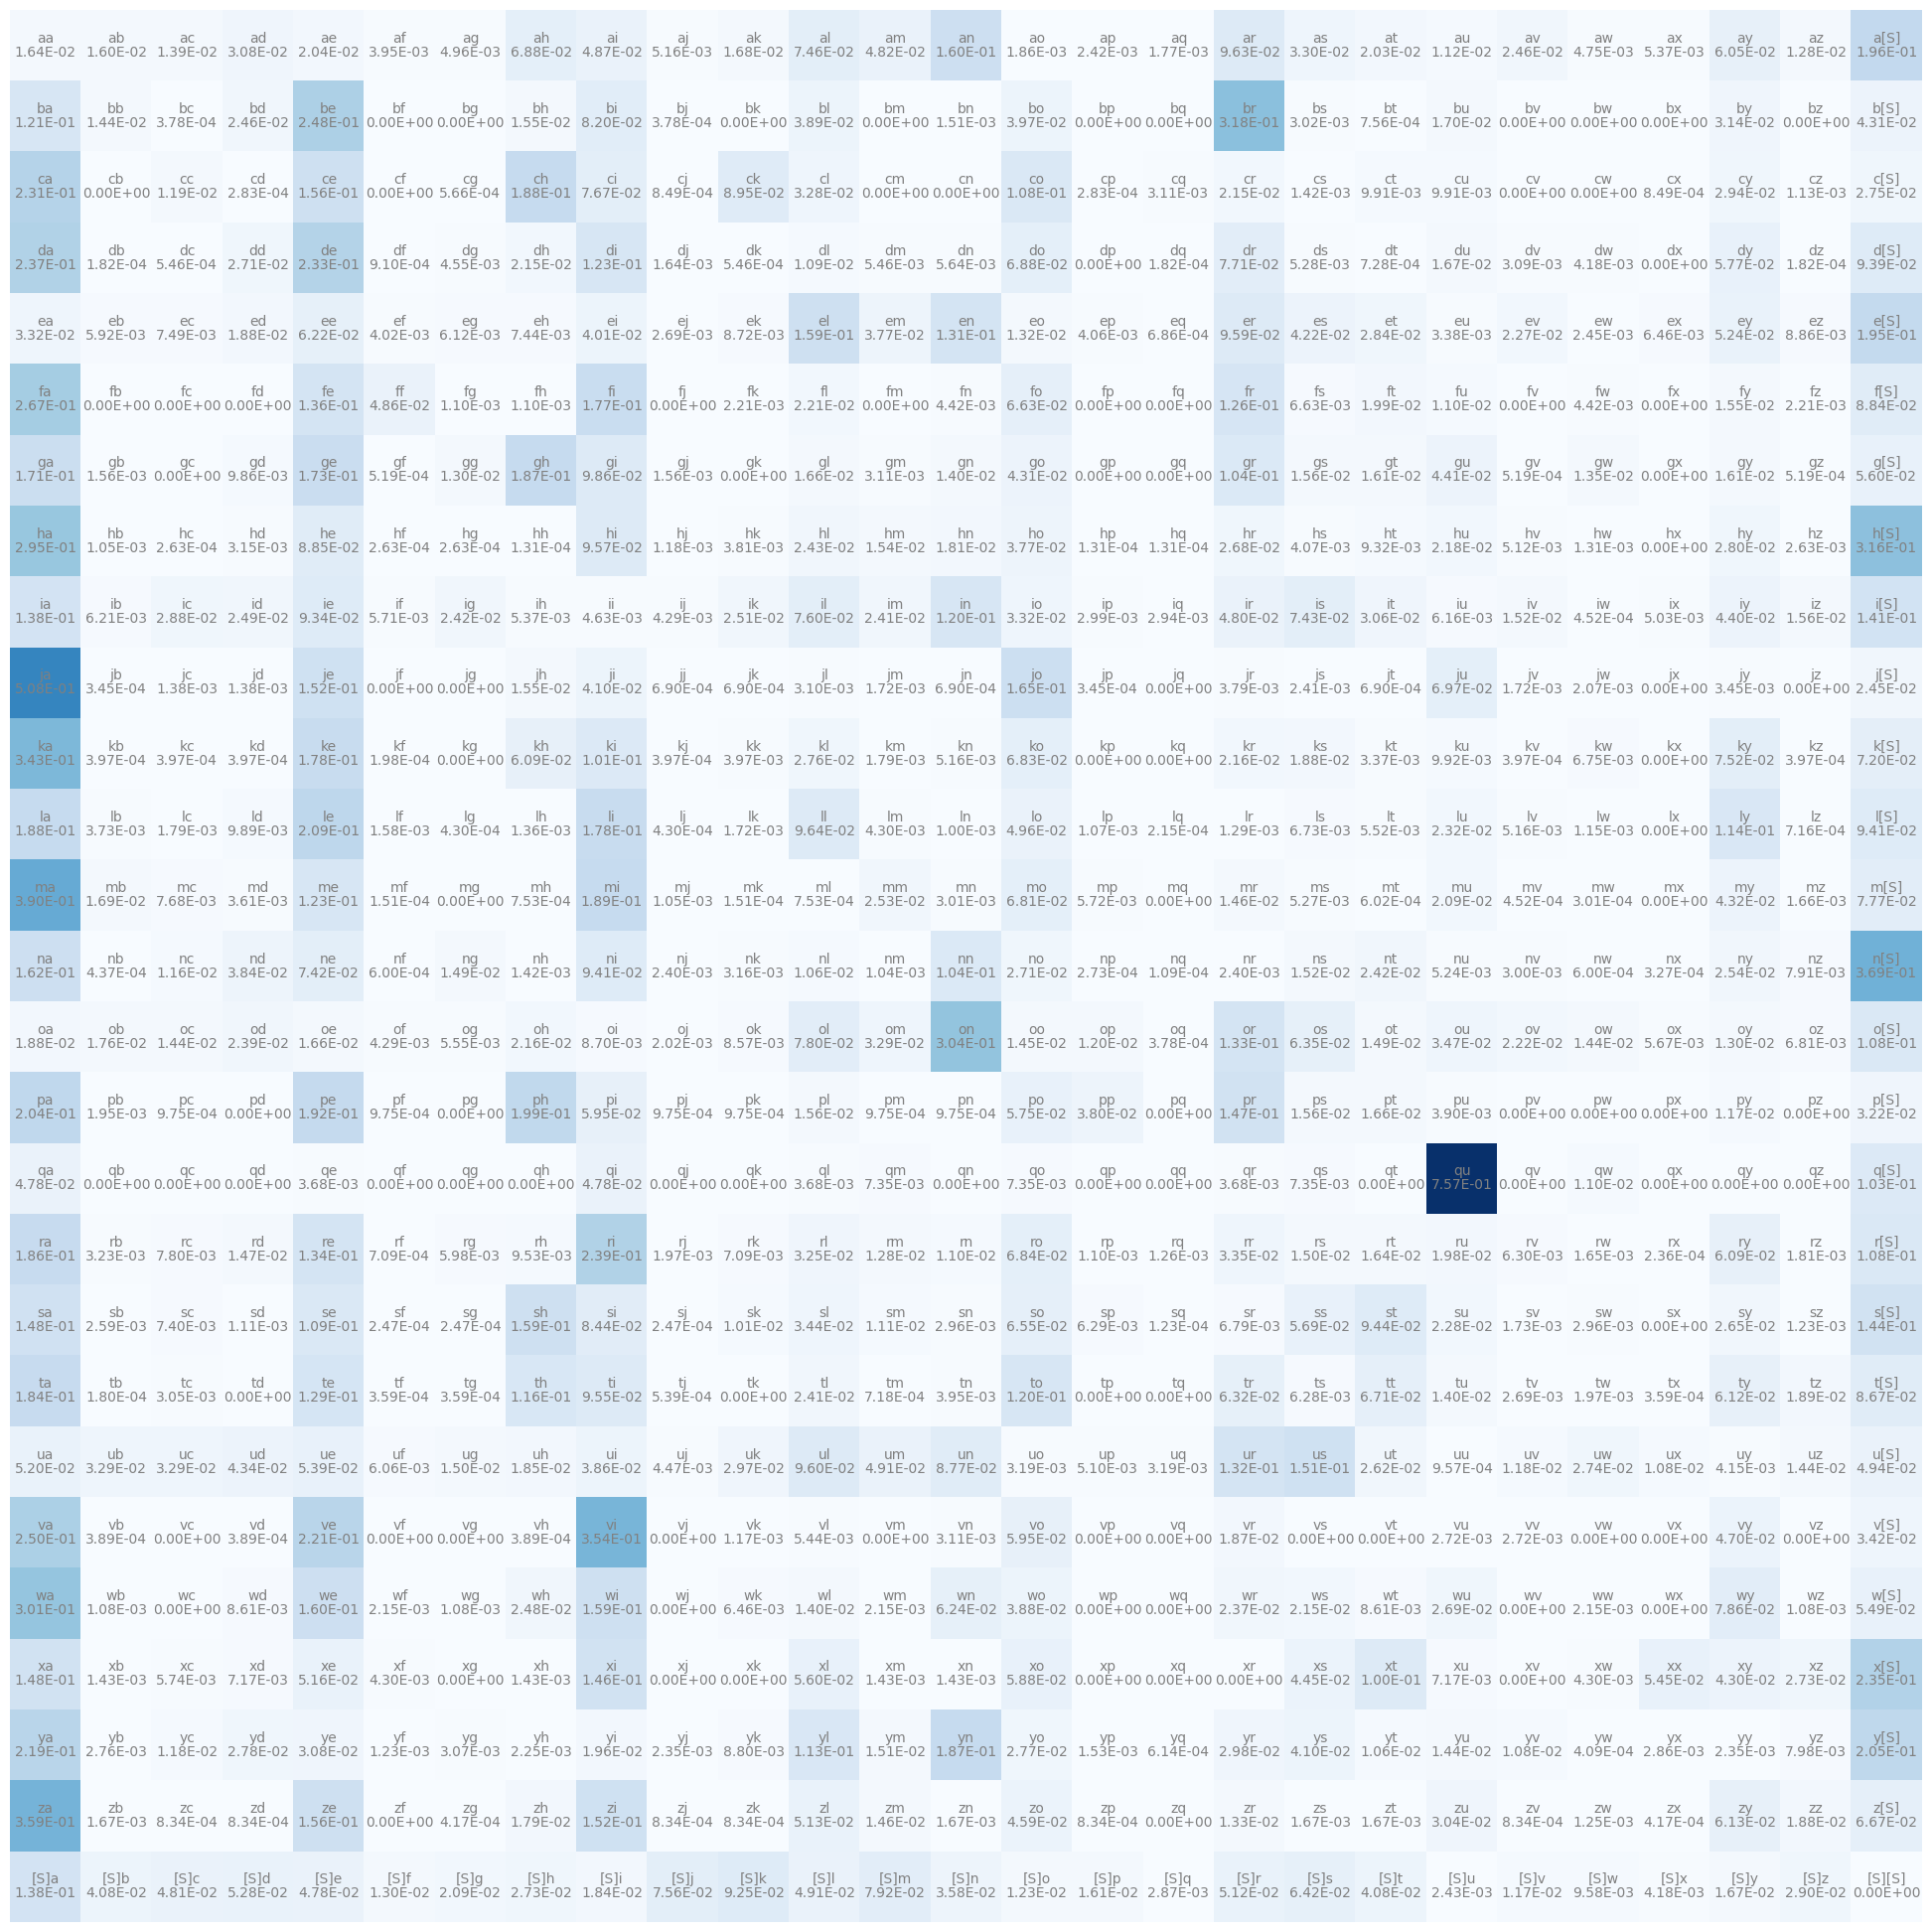

In [9]:
# Visualize the probabilities
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(25,25))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = index_to_char[i] + index_to_char[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, '%.2E' % P[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')
plt.savefig('images/bigram_table.png', dpi=300)

Questions
- Which token is most likely to start a sequence?
- Which token is most likely to end a sequence?
- Which token is most likely to follow token `v`?
- Which token pair has the highest probability according to the model?

### Generating with the bigram model

Now we can generate sequences using the bigram model. We will denote the model as $p_\theta$, where $\theta$ are the parameters of the model (i.e., the transition probabilities).

First, let's generate some first-tokens:

\begin{align*}
    x_1\sim p_\theta(\cdot|x_0)
\end{align*}

In [10]:
index = torch.multinomial(
    P[char_to_index['[S]']], 
    num_samples=10,
    replacement=True
)
# refer to https://docs.pytorch.org/docs/stable/generated/torch.multinomial.html to read more about the torch.multinomial
# It returns a tensor where each row contains num_samples indices sampled from the multinomial probability distribution 
# located in the corresponding row of the tensor input.
[index_to_char[i.item()] for i in index]

['d', 'o', 'n', 'm', 'l', 'k', 'm', 'l', 'n', 'n']

To generate full sequences, we will start with the `[S]` token and iteratively sample the next token based on the current token's distribution. This process will continue until we sample the `[S]` token again, indicating the end of the sequence.

Here is the step-by-step process:

1. Start with the `[S]` token.
2. Sample the next token based on the current token's distribution.
3. Append the sampled token to the sequence.
4. Use the sampled token as the new current token.
5. Repeat steps 2-4 until the `[S]` token is sampled again.

Let's implement this in the next code cell.

In [21]:
def generate_sequence():
    sequence = ['[S]']
    while True:
        current_char = sequence[-1]
        current_index = char_to_index[current_char]
        next_index = torch.multinomial(P[current_index], num_samples=1).item()
        next_char = index_to_char[next_index]
        if next_char == '[S]':
            break
        sequence.append(next_char)
    return ''.join(sequence[1:])

# Generate 10 sequences
generated_sequences = [generate_sequence() for _ in range(10)]
generated_sequences

['dio',
 'cymichal',
 'abeliain',
 'an',
 'di',
 'ty',
 'ey',
 'aro',
 'zckeison',
 'eeriaio']

Although the model is clearly not that good at generating new sequences (names), let's compare it to just uniformly sampling characters.

In [28]:
import random

def generate_uniform_sequence():
    characters = list(char_to_index.keys())
    sequence = ['[S]']
    while True:
        next_char = random.choice(characters)
        if next_char == '[S]':
            break
        sequence.append(next_char)
    return ''.join(sequence[1:])

# Generate 10 sequences
uniform_sequences = [generate_uniform_sequence() for _ in range(10)]
uniform_sequences

['nxxabrwvujojbhnkltwcgkzrtidfhuct',
 'vlomy',
 'kcvhlueezvntrrmk',
 'taiqgrzipy',
 'a',
 'zjf',
 'wzdrlzxutbsyo',
 'iuatbzgkjascqduooyvha',
 'esositddqzakeczoiruudysrxmjiooz',
 'cubgysekxuqhlruboqphsgwbylqbjbihlqgsadmbmgtpzkv']

The bigram model clearly has a bit more structure than this uniform baseline.

### Evaluating the model using log-likelihood and perplexity
To evaluate the model, we can compute the **log-likelihood** of sequences in a dataset. The log-likelihood of a sequence is given by:

\begin{align*}
\log p(x_1, x_2, \ldots, x_T) = \sum_{t=1}^{T} \log p(x_t \mid x_{t-1})
\end{align*}

where $ p(x_t \mid x_{t-1}) $ is the conditional probability of token $ x_t $ given the previous token $ x_{t-1} $. We use log probabilities to avoid numerical underflow when multiplying many probabilities together.

In [30]:
def log_likelihood(P, dataset):
    n = 0
    ll = 0
    for x in dataset:
        sequence = ['[S]'] + list(x) + ['[S]']
        for x1, x2 in zip(sequence, sequence[1:]):
            i = char_to_index[x1]
            j = char_to_index[x2]
            ll += torch.log(P[i, j])
            n += 1
    return ll, n

ll, n = log_likelihood(P, data)
print(f'Log likelihood: {ll.item():.4f}')
print(f'Average next-token log likelihood {ll.item() / n:.4f}')

Log likelihood: -559891.7500
Average next-token log likelihood -2.4541


It is common to report log-likelihood in terms of **perplexity**, which is defined on a per-token basis as:

\begin{align*}
\text{Perplexity} = \exp\left(-\frac{1}{N} \sum_{i=1}^{N} \log p(x_i \mid x_{i-1})\right)
\end{align*}

where $N$ is the total number of tokens in the dataset. Lower perplexity indicates a better model.

Check this great [blog post](https://thegradient.pub/understanding-evaluation-metrics-for-language-models/) for more details about perplexity and related quantities in language models.

In [31]:
def perplexity(model, dataset):
    ll, n = log_likelihood(model, dataset)
    return torch.exp(-ll / n).item()

perplexity(P, data)

11.635889053344727

**Wikipedia Definition of Preplexity**: 

                  “a measurement of how well a probability distribution or probability model predicts a sample."

So, 
* Low perplexity → good model, this means that the model predicts the text well, and it is less surprised by what comes next.
* High perplexity → worse model, this means that the model struggles to predict the text, it is more surprised by the actual sequence.

#### Evaluating on held-out data (suggested exercise 1 -- **Optional**)

Above, we evaluated the model on the training data. To evaluate generalization, we want to evaluate on a held-out set of sequences.

In this simple example, we did not hold out a set of test names. As an exercise, you can partition the dataset into training, validation, and test sequences, and evaluate the held-out validation and/or test perplexity.

A key consideration is that our model may assign **zero probability** to a sequence that it did not see in training, hence resulting in unbounded log-likelihood. To overcome this, you can implement **uniform smoothing** as described in the lecture. Namely, we add a fixed probability mass $\alpha$ to each next-token probability. 

**Suggested exercise 2:** generalize the model above to an $n$-gram model (e.g., n = 2, 3, 4, ...)

## A simple neural bigram model

Next we will frame the above model in terms of **learning** a model, i.e. $p(\cdot|x_{t-1})=W x_{t-1}$.


In [32]:
# Make a training set
xs, ys = [], []
for x in data:
    sequence = ['[S]'] + list(x) + ['[S]']
    for x1, x2 in zip(sequence, sequence[1:]):
        xs.append(char_to_index[x1])
        ys.append(char_to_index[x2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [33]:
xs[:10], ys[:10]

(tensor([26,  4, 12, 12,  0, 26, 14, 11,  8, 21]),
 tensor([ 4, 12, 12,  0, 26, 14, 11,  8, 21,  8]))

In [35]:
# how we can transform a single index to a meaninfull representation?
torch.nn.functional.one_hot(xs, num_classes=27)[:3]

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 1],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])

In [38]:
# W_ij is the probability of character j given character i
# so our W_ij will be a matrix of 27x27, we will initiaze it randomly
W = torch.randn(27, 27, requires_grad=True)
learning_rate = 20

def forward(x):
    xenc = torch.nn.functional.one_hot(x, num_classes=27).float()
    logits = xenc.matmul(W) # dim: (batch_size, 27)
    return logits

def nll_loss(logits, y):
    loss = -torch.nn.functional.log_softmax(logits, dim=1) # dim: (batch_size, 27)
    loss = loss[range(len(y)), y] # dim: (batch_size,)
    loss = loss.mean()
    return loss

for k in range(1000):
    logits = forward(xs)
    nll = nll_loss(logits, ys)
    loss = nll 

    W.grad = None
    loss.backward()
    if k % 100 == 0:
        print(f"loss at step {k}: ", loss.item())

    W.data -= learning_rate * W.grad


loss at step 0:  3.852292060852051
loss at step 100:  2.5154922008514404
loss at step 200:  2.4822356700897217
loss at step 300:  2.4709057807922363
loss at step 400:  2.4656834602355957
loss at step 500:  2.462859630584717
loss at step 600:  2.4611103534698486
loss at step 700:  2.459918737411499
loss at step 800:  2.459054708480835
loss at step 900:  2.458399772644043


In [39]:
# Now, let's calculate the log likelihood
P_ = torch.nn.functional.softmax(W, dim=1).detach()

ll, n = log_likelihood(P_, data)
print(f'Log likelihood: {ll.item():.4f}')
print(f'Average next-token log likelihood {ll.item() / n:.4f}')

Log likelihood: -560781.8125
Average next-token log likelihood -2.4580


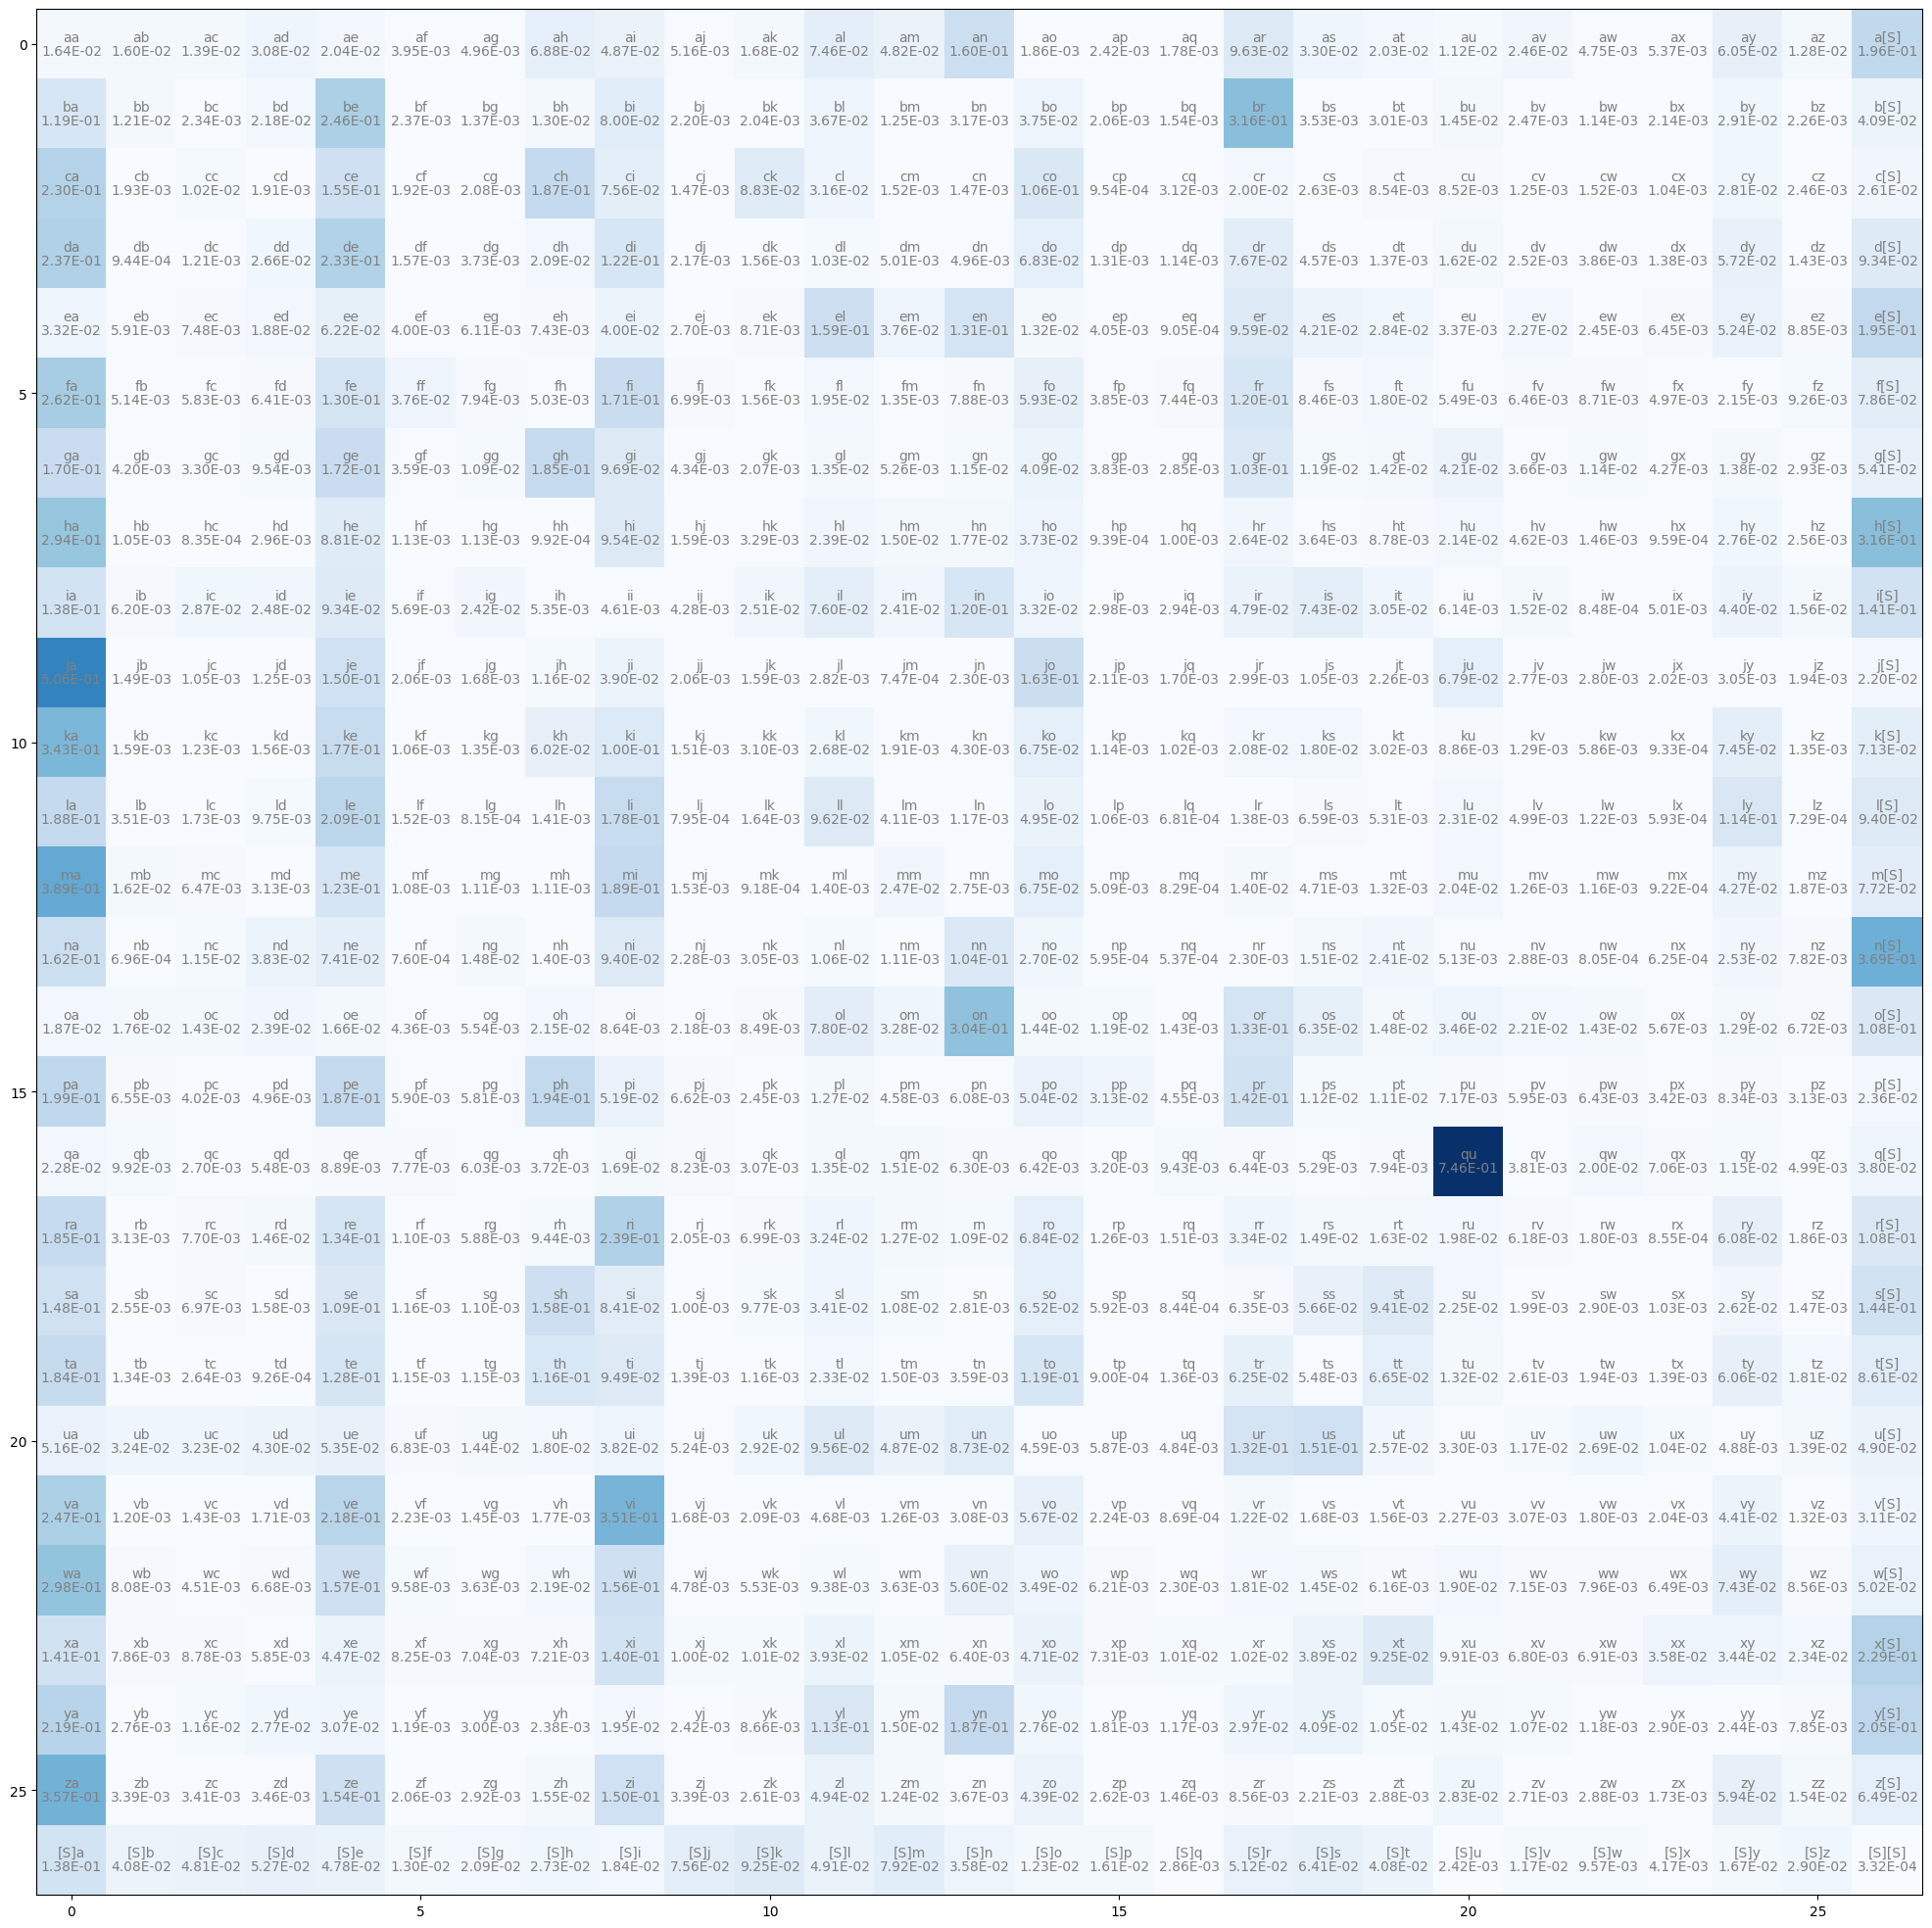

In [40]:
# Visualize the model's probabilities
plt.figure(figsize=(25,25))
plt.imshow(P_.numpy(), cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = index_to_char[i] + index_to_char[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, '%.2E' % P_[i, j].item(), ha="center", va="top", color='gray')

Questions
- Which token is most likely to start a sequence?
- Which token is most likely to end a sequence?
- Which token is most likely to follow token `v`?
- Which token pair has the highest probability according to the model?

We can see that our simple learned model is quite similar to the one that was based on word counts.

In the next notebooks, we will build better neural networks that improve the ability to model and generate sequences.